##Start by Importing the Necessary Libraries for the Project

###Random Move Policy is Defined Within the Globe (World, Environment and Population)

In [ ]:
#It is strongly encouraged that this program be run using Google Colab for Python
#All a user needs do is run each of the following cells one after the other and modify parameters as needed
#Here, we import all the libraries needed to run the written Program
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
!pip install ipython --upgrade

##Defining the Globe (World, Environment and Population)

In [ ]:
class Agent: #Defining the Agents and the concerned behavioural functions
  def __init__(self, typeAgent, env,n):

    self.type_=typeAgent

    L=env.width
    W=env.height
    locx=np.random.randint(L)
    locy=np.random.randint(W)
    while (locx,locy) in env.occupiedList:
      locx=np.random.randint(L)
      locy=np.random.randint(W)
    self.loc=(locx,locy)
    env.occupied(self)
    self.suitable_pos=[]
    self.friends=np.random.choice([i for i in range(env.npop)],n, replace=False)
    
    k=3 #Modify the value of k here

   

  def socialnetworkpolicy(self,env,p,pop,q=100): #Defining the Social Network Recommendation Policy
     
     x,y=self.loc
     startpx=int(x-p/2)
     endpx=int(x+p/2)

     startpy=int(y-p/2)
     endpy=int(y+p/2)
     suitable=[]

     for i in range(startpx,endpx):
       for j in range(startpy,endpy):
         if (i,j) in env.occupiedList:
           idx=env.occupiedList.index((i,j))
           if self.type_ == env.AgentColours[idx]:
             suitable.append((i,j))

     for ag in pop:
        for s in suitable:
          ag.suitable_pos.append(s)

     # if there is no suitable position found, we move as in policy 1 (Random Policy)
     if len(self.suitable_pos):
        self.random_move_policy(env,q)  

     else:
        
        counter=0

        while True: 
          if counter>=10:
            self.random_move_policy(env,q)
            break
          loc2=np.random.choice(self.suitable_pos)  #Picking random points
          
          idx=env.occupiedList.index(loc2)  
          
          if self.type_==env.AgentColours[idx]:
              x,y=loc2
              if x<self.loc[0] :
                self.move('Left',env)


              elif x>self.loc[0]:
                self.move('Right',env)
              
              elif y<self.loc[1]:
                self.move('Up',env)
                
              elif y>self.loc[1]:
                self.move('Down',env)

              break

          counter+1



  def move(self,direction,env): #Defining possible move options, for one agent at a time

    x,y=self.loc
    
    idx2=env.occupiedList.index(self.loc)
  
    if direction == 'Left':
      x1=x-1
      y1=y
    elif direction == 'Right':
      x1=x+1
      y1=y
    elif direction == 'Up':
      y1=y-1
      x1=x
    elif direction == 'Down':
      y1=y+1
      x1=x
    
    if x1>=env.width:
      x1=0
    if y1>=env.height:
      y1=0
    
    if x1<0:
      x1=env.width-1
    if y1<0:
      y1=env.height-1
    # Ensuring that agents are not overlapping
    if not((x1,y1) in env.occupiedList):
      env.occupiedList.pop(idx2)
      #env.AgentColours.pop(idx)
      self.loc = (x1,y1)
      env.occupiedList.insert(idx2,self.loc)
      #env.AgentColours.append(self.type_)



  def random_move_policy(self,env,q): #Defining the Random Policy move
    agentloc=self.loc
    x,y=agentloc
    c=self.type_
    checklist = [(x-1,y),(x+1,y), (x,y-1), (x,y+1)]
    

    locations=env.getEmpty(q)
    locations=self.sortLocation(locations)
    
    ishappy,happyindex = env.homophily(self.loc,c)

    if ishappy: #Check Agent's state, happy or not happy
      pass
      return 
    #d=np.random.choice(['Left','Right','Up','Down'])
    
    #self.move(d,env)  
    
    for location in locations:
      _,happyindexnew=env.homophily(location,c)
      if happyindexnew>happyindex:

        x,y=location
        if x<self.loc[0] :
          self.move('Left',env)
          break

        elif x>self.loc[0]:
          self.move('Right',env)
          break
        
        elif y<self.loc[1]:
          self.move('Up',env)
          break
        elif y>self.loc[1]:
          self.move('Down',env)
          break
    


  def sortLocation(self,locations):
    
    x,y=self.loc
    distances=[np.sqrt((x-i[0])**2+(y-i[1])**2) for i in locations]
    #distances=[abs(x-i[0])+abs(y-i[1]) for i in locations] #Basiru Modified-Random Policy Move
    idx=np.argsort(distances)
    
    locations=[locations[idx[i]] for i in range(len(locations))]
    return locations
    


class world: #Defining the World and the homophilic behaviour
  def __init__(self, L,W,npop):
    self.width=L
    self.height=W
    self.occupiedList=[]
    self.AgentColours=[]
    self.npop=npop
  


  def occupied(self,Agent): #Check to see what positions are occupied
    self.occupiedList.append(Agent.loc)
    self.AgentColours.append(Agent.type_)
 


  def getEmpty(self,q): #Get empty/available spaces
    x=np.arange(self.width)
    y=np.arange(self.height)
    
    locations=[]
    while True:
      
      xx=np.random.choice(x)
      yy=np.random.choice(y)
      
      if (xx,yy) in self.occupiedList:
        continue

      locations.append([xx,yy])
      if len(locations)==q:
        break
      
    return locations



  def homophily(self,loc,c,k=3):  #Again modify the value of k here
  
    isHappy = False

    count=0
    cc=0
    x,y=loc
    neighboorhoods = [(x-1,y),(x+1,y),(x,y-1),(x,y+1),(x+1,y+1),(x-1,y-1)]
    
    for n in neighboorhoods:
      if n in self.occupiedList:
        idx=self.occupiedList.index(n)
        if self.AgentColours[idx]==c :
          count+=1

    if count>=k:
      isHappy = True
    
    return isHappy,count

In [ ]:
def population(env,N,n): #Defining the Population for Plot/Model Visualization
  pop=[]
  colors=['Red','Blue']
  for i in range(N):
    c=np.random.choice(colors)
    a=Agent(c,env,n)
    pop.append(a)

  return pop



def get_x_y(occupiedList,colors):
  xs=[]
  ys=[]
  for x,y in occupiedList:
    xs.append(x)
    ys.append(y)

  idx=[]
  for c in colors:
    if c=='Red':
      idx.append(1)
    else:
      idx.append(0)

  return np.array(xs),np.array(ys),np.array(idx)



  def update_plot(idx): #Updating plots from time to time

    lines.set_data(xs[idx==1],ys[idx==1])
    lines2.set_data(xs[idx==0],ys[idx==0])

    return lines, lines2

## Defining the Social Network Policy

### Please modify parameters here and ensure consistency

In [ ]:
def socialnetwork(pp,n,epoch): #Outlining the Social Network Recommendation Policy and its parameters

    #Modify parameters here

    env=world(40,40,N)
    q=100
    n=5  #number of friends
    pp=3  

    pop=population(env,N,n)
    xs,ys,idx = get_x_y(env.occupiedList, env.AgentColours)
    plt.scatter(xs[idx==1],ys[idx==1],color='r',marker='s')
    plt.scatter(xs[idx==0],ys[idx==0],color='b',marker='s')
    plt.show()


    clear_output(wait=True)
    meanHappines=[]
   
    for i in range(epoch):
      
      idx=np.random.randint(N)
      
      t=0
      for p in pop:
        check,r=env.homophily(p.loc,p.type_)
        t+=int(check)
      meanHappines.append(t/N)  
      pop[idx].socialnetworkpolicy(env,pp,pop)

      xs,ys,idx = get_x_y(env.occupiedList, env.AgentColours)
      #Visualizing the plot
      plt.scatter(xs[idx==1],ys[idx==1], color='r',marker='s')
      plt.scatter(xs[idx==0],ys[idx==0],color='b',marker='s')
      plt.xlabel('x-axis')
      plt.ylabel('y-axis')

      plt.title("Modified-Social Network Policy, Step = %d, Mean happiness = %f" %(i,t/N))
      plt.suptitle("Schelling's Segregation Model",size=12, y=1.02)
      plt.grid()
      plt.show()
      
      clear_output(wait=True)
      
    return meanHappines

##Visualizing Agents in their Initial Positions (Zeroth Positions)

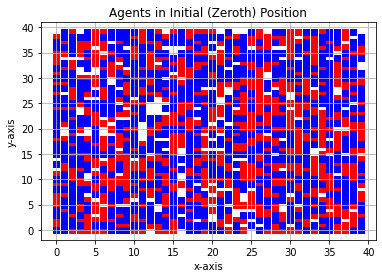

In [ ]:
#Visualize world and population parameters here
#Double-check to ensure consistent system parameters
N=1400 #Modify number of Agents here
env=world(40,40,N) #Modify environment grid size here
n=5  #NModify umber of friends here
pop=population(env,N,n)
xs,ys,idx = get_x_y(env.occupiedList, env.AgentColours)
plt.scatter(xs[idx==1],ys[idx==1], color='r',marker='s')
plt.scatter(xs[idx==0],ys[idx==0],color='b',marker='s')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.title('Agents in Initial (Zeroth) Position')
plt.grid()
plt.show()

## Simulations Begin

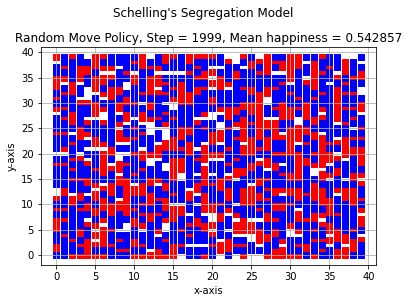

In [ ]:
#Modify parameters here
#Simulations for Problem 1 (Random Move Policy)

q=100 #Modify q-value here #q is no of attempts to check available positions before picking a best
clear_output(wait=True)
epochs = 2000
TforPlot = []
for i in range(epochs):
  
  idx=np.random.randint(N)
  
  t=0
  for p in pop:
    check,r=env.homophily(p.loc,p.type_)
    t+=int(check)

  pop[idx].random_move_policy(env,q)

  xs,ys,idx = get_x_y(env.occupiedList, env.AgentColours)
  TforPlot.append(t/N) #Storing values for the Mean Happiness
  plt.scatter(xs[idx==1],ys[idx==1], color='r',marker='s')
  plt.scatter(xs[idx==0],ys[idx==0],color='b',marker='s')
  plt.xlabel('x-axis')
  plt.ylabel('y-axis')
  plt.title("Random Move Policy, Step = %d, Mean happiness = %f" %(i,t/N))
  plt.suptitle("Schelling's Segregation Model",size=12, y=1.02)
  plt.grid()
  plt.show()

  clear_output(wait=True)

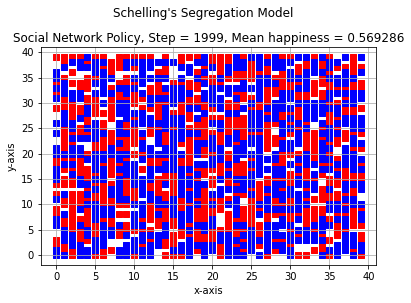

In [ ]:
#Simulations for Problem 1 (Social-Network Policy)

ns=[5,10,20]
ps=[3,5]

epoch=2000

meanH=[]
for n in ns:
  for p in ps:
    meanH.append(socialnetwork(p,n,epoch))

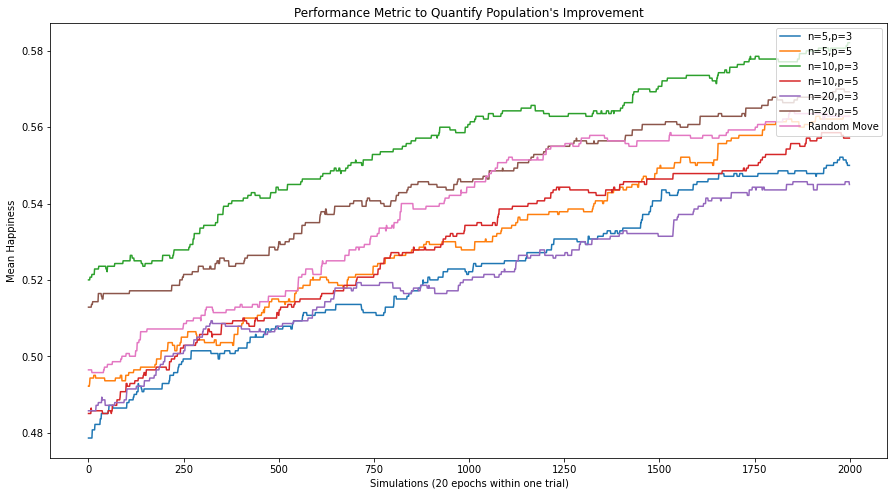

In [ ]:
labels=['n=5,p=3','n=5,p=5','n=10,p=3','n=10,p=5','n=20,p=3','n=20,p=5']
list_epochs=[i for i in range(epoch)]

plt.figure(figsize = (15,8))
for l in range(len(labels)):
  plt.plot(list_epochs,meanH[l],label=labels[l])

plt.xlabel('Simulations (20 epochs within one trial)')
plt.ylabel('Mean Happiness')
plt.title("Performance Metric to Quantify Population's Improvement")
plt.plot(TforPlot,label='Random Move')
plt.legend(loc='upper right')

plt.show()

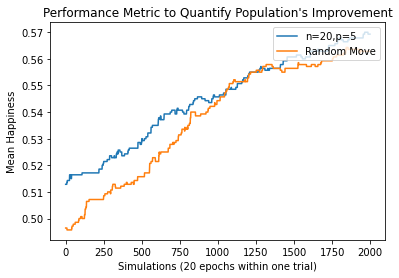

In [ ]:
labels=['n=5,p=3','n=5,p=5','n=10,p=3','n=10,p=5','n=20,p=3','n=20,p=5']
list_epochs=[i for i in range(epoch)]

#plt.figure(figsize = (15,8))

plt.plot(meanH[5],label=labels[5])

plt.xlabel('Simulations (20 epochs within one trial)')
plt.ylabel('Mean Happiness')
plt.title("Performance Metric to Quantify Population's Improvement")
plt.plot(TforPlot,label='Random Move')
plt.legend(loc='upper right')

plt.show()

#Modified Social Network Move Policy - Oluwaseun Adekoya
###Agents have only friends of their own type

In [ ]:
def modifiedsocialnetwork(pp,n,epoch):

    def __init__(self, typeAgent, env,n):

      self.type_=typeAgent

      L=env.width
      W=env.height
      locx=np.random.randint(L)
      locy=np.random.randint(W)
      while (locx,locy) in env.occupiedList:
        locx=np.random.randint(L)
        locy=np.random.randint(W)
      self.loc=(locx,locy)
      env.occupied(self)
      self.suitable_pos=[]
      self.friends=np.random.choice([i for i in range(env.npop)],n, replace=False)
      

      x,y=self.loc
      startpx=int(x-p/2)
      endpx=int(x+p/2)

      startpy=int(y-p/2)
      endpy=int(y+p/2)
      suitable=[]
      friendTypeTrue=[] #Checking if found friends are exactly the same type as current Agent
      for i in range(startpx,endpx):
       for j in range(startpy,endpy):
         if (i,j) in env.occupiedList:
           idx=env.occupiedList.index((i,j))
           if self.friends==typeAgent:
             friendTypeTrue.append((i,j))
           else:
             pass
             return


    #Modify parameters here

    env=world(40,40,N)
    q=100
    n=5  #number of friends
    pp=3  

    pop=population(env,N,n)
    xs,ys,idx = get_x_y(env.occupiedList, env.AgentColours)
    plt.scatter(xs[idx==1],ys[idx==1],color='r',marker='s')
    plt.scatter(xs[idx==0],ys[idx==0],color='b',marker='s')
    plt.show()


    clear_output(wait=True)
    meanHappines=[]
   
    for i in range(epoch):
      
      idx=np.random.randint(N)
      
      t=0
      for p in pop:
        check,r=env.homophily(p.loc,p.type_)
        t+=int(check)
      meanHappines.append(t/N)  
      pop[idx].socialnetworkpolicy(env,pp,pop)

      xs,ys,idx = get_x_y(env.occupiedList, env.AgentColours)

      plt.scatter(xs[idx==1],ys[idx==1], color='r',marker='s')
      plt.scatter(xs[idx==0],ys[idx==0],color='b',marker='s')
      plt.xlabel('x-axis')
      plt.ylabel('y-axis')

      plt.title("Social Network Policy, Step = %d, Mean happiness = %f" %(i,t/N))
      plt.suptitle("Schelling's Segregation Model",size=12, y=1.02)
      plt.grid()
      plt.show()
      
      clear_output(wait=True)
      
    return meanHappines

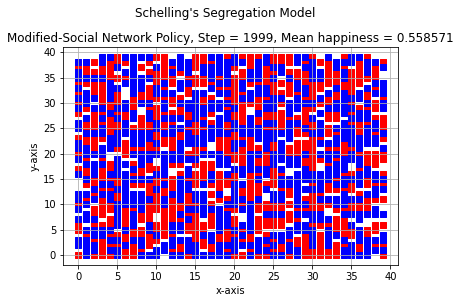

In [ ]:
#Simulations for Oluwaseun's Modified Policy 2 (Modified-Social-Network Policy)

N=1400
ns=[5,10,20]
ps=[3,5]
epoch=2000
q=100

epoch=2000

SeunmeanH=[]
for n in ns:
  for p in ps:
    meanH.append(socialnetwork(p,n,epoch))

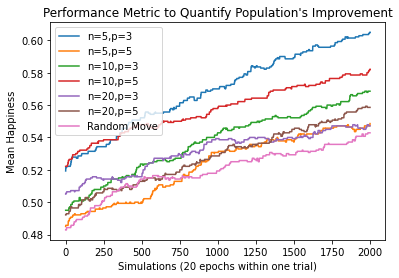

In [ ]:
labels=['n=5,p=3','n=5,p=5','n=10,p=3','n=10,p=5','n=20,p=3','n=20,p=5']
list_epochs=[i for i in range(epoch)]

#plt.figure(figsize = (15,8))
for l in range(len(labels)):
  plt.plot(list_epochs,meanH[l],label=labels[l])

plt.xlabel('Simulations (20 epochs within one trial)')
plt.ylabel('Mean Happiness')
plt.title("Performance Metric to Quantify Population's Improvement")
plt.plot(TforPlot,label='Random Move')
plt.legend(loc='upper left')

plt.show()

# Modified Random Policy Move - Basiru Olafuyi
# Distance metric changed to Manhattan Distance

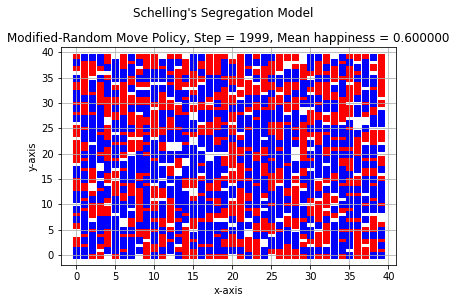

In [ ]:
#Modify parameters here
#Simulations for Basiru's Policy 3 (Modified-Random Move Policy)


def modifiedrandom_move_policy(self,env,q): #Defining the Basiru's Modified Random Policy move
    agentloc=self.loc
    x,y=agentloc
    c=self.type_
    checklist = [(x-1,y),(x+1,y), (x,y-1), (x,y+1)]
    

    locations=env.getEmpty(q)
    locations=self.sortLocation(locations)
    
    ishappy,happyindex = env.homophily(self.loc,c)

    if ishappy: #Check Agent's state, happy or not happy
      pass
      return 
    #d=np.random.choice(['Left','Right','Up','Down'])
    
    #self.move(d,env)  
    
    for location in locations:
      _,happyindexnew=env.homophily(location,c)
      if happyindexnew>happyindex:

        x,y=location
        if x<self.loc[0] :
          self.move('Left',env)
          break

        elif x>self.loc[0]:
          self.move('Right',env)
          break
        
        elif y<self.loc[1]:
          self.move('Up',env)
          break
        elif y>self.loc[1]:
          self.move('Down',env)
          break

def sortLocation(self,locations):
    
    x,y=self.loc
    distances=[abs(x-i[0])+abs(y-i[1]) for i in locations] #Basiru Modified-Random Policy Move
    idx=np.argsort(distances)
    
    locations=[locations[idx[i]] for i in range(len(locations))]
    return locations


#Model Simulation
q=100 #Modify q-value here #q is no of attempts to check available positions before picking a best
clear_output(wait=True)
epochs = 2000
BasirforPlot = []
for i in range(epochs):
  
  idx=np.random.randint(N)
  
  t=0
  for p in pop:
    check,r=env.homophily(p.loc,p.type_)
    t+=int(check)

  pop[idx].random_move_policy(env,q)

  xs,ys,idx = get_x_y(env.occupiedList, env.AgentColours)
  BasirforPlot.append(t/N) #Storing values for the Mean Happiness
  plt.scatter(xs[idx==1],ys[idx==1], color='r',marker='s')
  plt.scatter(xs[idx==0],ys[idx==0],color='b',marker='s')
  plt.xlabel('x-axis')
  plt.ylabel('y-axis')
  plt.title("Modified-Random Move Policy, Step = %d, Mean happiness = %f" %(i,t/N))
  plt.suptitle("Schelling's Segregation Model",size=12, y=1.02)
  plt.grid()
  plt.show()

  clear_output(wait=True)

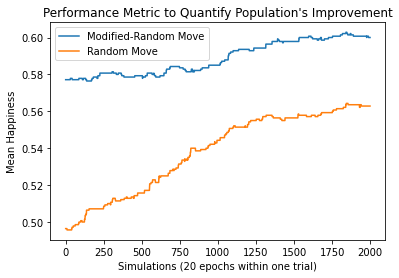

In [ ]:
plt.plot(BasirforPlot,label='Modified-Random Move')

plt.xlabel('Simulations (20 epochs within one trial)')
plt.ylabel('Mean Happiness')
plt.title("Performance Metric to Quantify Population's Improvement")
plt.plot(TforPlot,label='Random Move')
plt.legend(loc='upper left')

plt.show()